# Benchmarking Runtime and Memory Consumption Across Tools

# Import and Configuration

In [25]:
import os
import re
import sys
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Make utils.* importable when running from anywhere under bakeoff/
_HERE = Path.cwd()
for _cand in (_HERE / 'scripts' / 'analysis', _HERE, _HERE / 'bakeoff' / 'scripts' / 'analysis'):
    if (_cand / 'utils' / '__init__.py').exists() and str(_cand) not in sys.path:
        sys.path.insert(0, str(_cand))
        break
from utils.results import (
    extract_hosts_from_reports, extract_data_groups_from_reports,
    find_latest_analysis_prep_ts, save_csv, save_fig,
)


In [26]:
# ---------- CONFIG ----------

SAVE = True

REPORTS_ROOT = Path("/home/Users/pacbio_bakeoff/bakeoff/reports")
ROOT_BY_DB = {
    "unified": REPORTS_ROOT / "unified-reports",
    "default": REPORTS_ROOT / "default-reports",
}
DATA_GROUP = "ZymoMockD6331"  # ZymoMockD6331 or simulated

# Outputs of this notebook are scoped by (host, data-group); inputs come from
# the analysis_prep run that produced the detection metrics we plot F1 from.

# Run host: detected from state-log filenames; pin manually if ambiguous.
_hosts = extract_hosts_from_reports(ROOT_BY_DB.values())
if len(_hosts) == 1:
    HOST = next(iter(_hosts))
elif len(_hosts) == 0:
    raise RuntimeError(
        f"No run_state_<host>_<ts>.log found under {list(ROOT_BY_DB.values())}. "
        "Set HOST manually here."
    )
else:
    raise RuntimeError(f"Multiple hosts in state logs: {_hosts}. Set HOST manually here.")

# Auto-detect data-group, but respect a manual override set above.
# - 0 groups on disk: error.
# - 1 group on disk: pick it (ignore any manual override silently).
# - >1 groups: keep the manual DATA_GROUP if it's one of them; error otherwise.
_groups = extract_data_groups_from_reports(ROOT_BY_DB.values())
if len(_groups) == 0:
    raise RuntimeError("No data-group subdirs found under report roots.")
elif len(_groups) == 1:
    DATA_GROUP = next(iter(_groups))
elif DATA_GROUP not in _groups:
    raise RuntimeError(
        f"Multiple data groups present: {sorted(_groups)} and "
        f"DATA_GROUP={DATA_GROUP!r} is not one of them. "
        "Set DATA_GROUP to one of those values."
    )
# else: multiple groups, manual DATA_GROUP is in them — keep it.

# Detection metrics live under the analysis_prep run that wrote them; this is
# input, not where this notebook stores anything.
RESULTS_ROOT        = Path("/home/Users/pacbio_bakeoff/bakeoff/results")
ANALYSIS_PREP_TS    = find_latest_analysis_prep_ts(RESULTS_ROOT)  # or pin: ANALYSIS_PREP_TS = "YYYYMMDD_HHMMSS"
DETECTION_THRESHOLD = "0.001"
DETECTION_ROOT      = RESULTS_ROOT / ANALYSIS_PREP_TS / "detection" / f"threshold_{DETECTION_THRESHOLD}"

READ_STATS_PATH = "/home/Users/pacbio_bakeoff/bakeoff/data/read_stats/read_stats.csv"

# Outputs: results/resource-benchmark/<host>/<data-group>/{tables,figures}/
OUT_DIR     = RESULTS_ROOT / "resource-benchmark" / HOST / DATA_GROUP
TABLES_DIR  = OUT_DIR / "tables"
FIGURES_DIR = OUT_DIR / "figures"
OUT_PREFIX  = f"resource_{DATA_GROUP}"

N_THREADS = 50

SELECTED_TOOL_DBS = [
    "Kraken2_unified",
    "Centrifuge_unified",
    "Centrifuger_unified",
    "Ganon2_unified",
    "Sourmash_unified",
    "Sylph_unified",
]

_cmap = plt.get_cmap("tab10")
TOOL_COLORS = {
    "Centrifuge":  _cmap(0),
    "Centrifuger": _cmap(1),
    "Kraken2":     _cmap(2),
    "Ganon2":      _cmap(3),
    "Sourmash":    _cmap(4),
    "Sylph":       _cmap(5),
}
DB_ALPHA = {"default": 0.35, "unified": 0.95}
BASE_TOOL_ORDER = ["Centrifuge", "Centrifuger", "Kraken2", "Ganon2", "Sourmash", "Sylph"]

print(f"host        : {HOST}")
print(f"data group  : {DATA_GROUP}")
print(f"OUT_DIR     : {OUT_DIR}   (SAVE={SAVE})")
print(f"analysis_prep ts: {ANALYSIS_PREP_TS}")
print(f"detection root  : {DETECTION_ROOT}")


host        : gho
data group  : ZymoMockD6331
OUT_DIR     : /home/Users/pacbio_bakeoff/bakeoff/results/resource-benchmark/gho/ZymoMockD6331   (SAVE=True)
analysis_prep ts: 20260531_212522
detection root  : /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/detection/threshold_0.001


# Loading data

In [27]:
def build_log_dirs(selected_tool_dbs):
    """
    Return {tool_db -> sorted list of <tool>-logs dirs}.

    Walks <ROOT_BY_DB[db]>/<dataset>/<tech>/<base>-logs/, case-insensitive
    on the tool name (e.g. ganon2-logs matches Ganon2).
    """
    out = {}
    for tool_db in selected_tool_dbs:
        base, db = tool_db.split("_", 1)
        all_log_dirs = glob.glob(os.path.join(ROOT_BY_DB[db], DATA_GROUP, "*", "*-logs"))
        out[tool_db] = sorted({
            d for d in all_log_dirs
            if os.path.basename(d)[:-5].lower() == base.lower()
        })
    return out


In [28]:
LOG_DIRS = build_log_dirs(SELECTED_TOOL_DBS)

for tool, dirs in LOG_DIRS.items():
    print(tool, len(dirs))
    for d in dirs:
        print("  ", d)


Kraken2_unified 2
   /home/Users/pacbio_bakeoff/bakeoff/reports/unified-reports/ZymoMockD6331/ont/Kraken2-logs
   /home/Users/pacbio_bakeoff/bakeoff/reports/unified-reports/ZymoMockD6331/pacbio/Kraken2-logs
Centrifuge_unified 2
   /home/Users/pacbio_bakeoff/bakeoff/reports/unified-reports/ZymoMockD6331/ont/Centrifuge-logs
   /home/Users/pacbio_bakeoff/bakeoff/reports/unified-reports/ZymoMockD6331/pacbio/Centrifuge-logs
Centrifuger_unified 2
   /home/Users/pacbio_bakeoff/bakeoff/reports/unified-reports/ZymoMockD6331/ont/Centrifuger-logs
   /home/Users/pacbio_bakeoff/bakeoff/reports/unified-reports/ZymoMockD6331/pacbio/Centrifuger-logs
Ganon2_unified 2
   /home/Users/pacbio_bakeoff/bakeoff/reports/unified-reports/ZymoMockD6331/ont/ganon2-logs
   /home/Users/pacbio_bakeoff/bakeoff/reports/unified-reports/ZymoMockD6331/pacbio/ganon2-logs
Sourmash_unified 2
   /home/Users/pacbio_bakeoff/bakeoff/reports/unified-reports/ZymoMockD6331/ont/sourmash-logs
   /home/Users/pacbio_bakeoff/bakeoff/rep

In [29]:
def discover_metrics_paths(detection_root, ranks=("species", "genus")):
    """
    Find all metrics_<rank>.csv files under
    <detection_root>/<dataset>/table/metrics_<rank>.csv.
    """
    paths = []
    for dataset_dir in sorted(glob.glob(os.path.join(detection_root, "*"))):
        if not os.path.isdir(dataset_dir):
            continue
        for rank in ranks:
            p = os.path.join(dataset_dir, "tables", f"metrics_{rank}.csv")
            if os.path.isfile(p):
                paths.append(p)
    return paths


def _dataset_from_metrics_path(path):
    """metrics file lives at <root>/<dataset>/table/metrics_*.csv"""
    return os.path.basename(os.path.dirname(os.path.dirname(path)))


In [30]:
def load_metrics_files(metrics_paths, selected_tool_dbs):
    """
    Load detection metrics from a list of metrics_<rank>.csv files.

    Each file has columns:
      rank, tool, TP, FP, FN, TN, precision, recall, F1
    where `tool` is e.g. "Kraken2_unified".

    Returns a long-form DataFrame with:
      dataset, rank, tool, tool_db, db, TP, FP, FN, TN, Precision, Recall, F1
    """
    frames = []
    for p in metrics_paths:
        df = pd.read_csv(p)
        df["dataset"] = _dataset_from_metrics_path(p)
        df = df.rename(columns={"precision": "Precision", "recall": "Recall", "f1": "F1"})

        df["tool"] = df["tool"].astype(str).str.strip()
        df = df[df["tool"].isin(selected_tool_dbs)]
        if df.empty:
            continue

        df["tool_db"] = df["tool"]
        split = df["tool"].str.rsplit("_", n=1, expand=True)
        df["tool"] = split[0]
        df["db"]   = split[1].str.lower()
        frames.append(df)

    if not frames:
        print("[WARN] No valid metrics loaded.")
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


In [31]:
METRICS_PATHS = discover_metrics_paths(DETECTION_ROOT)
print(f"Found {len(METRICS_PATHS)} metrics files:")
for p in METRICS_PATHS:
    print(" ", p)

metrics = load_metrics_files(METRICS_PATHS, SELECTED_TOOL_DBS)
metrics


Found 12 metrics files:
  /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/detection/threshold_0.001/ZymoMockD6331_ont_D6331_Qiagen/tables/metrics_species.csv
  /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/detection/threshold_0.001/ZymoMockD6331_ont_D6331_Qiagen/tables/metrics_genus.csv
  /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/detection/threshold_0.001/ZymoMockD6331_ont_D6331_Zymo/tables/metrics_species.csv
  /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/detection/threshold_0.001/ZymoMockD6331_ont_D6331_Zymo/tables/metrics_genus.csv
  /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/detection/threshold_0.001/ZymoMockD6331_pacbio_SRR13128013/tables/metrics_species.csv
  /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/detection/threshold_0.001/ZymoMockD6331_pacbio_SRR13128013/tables/metrics_genus.csv
  /home/Users/pacbio_bakeoff/bakeoff/results/20260531_212522/detection/threshold_0.001/ZymoMockD6331_pacbio_SRR1

,rank,tool,TP,FP,FN,TN,Precision,Recall,F1,dataset,tool_db,db
0,species,Centrifuge,17,529,0,817,0.031136,1.000000,0.060391,ZymoMockD6331_ont_D6331_Qiagen,Centrifuge_unified,unified
1,species,Centrifuger,16,107,1,184,0.130081,0.941176,0.228571,ZymoMockD6331_ont_D6331_Qiagen,Centrifuger_unified,unified
2,species,Ganon2,16,38,1,58,0.296296,0.941176,0.450704,ZymoMockD6331_ont_D6331_Qiagen,Ganon2_unified,unified
3,species,Kraken2,16,209,1,238,0.071111,0.941176,0.132231,ZymoMockD6331_ont_D6331_Qiagen,Kraken2_unified,unified
4,species,Sourmash,15,23,2,0,0.394737,0.882353,0.545455,ZymoMockD6331_ont_D6331_Qiagen,Sourmash_unified,unified
...,...,...,...,...,...,...,...,...,...,...,...,...
67,genus,Centrifuger,65,50,0,180,0.565217,1.000000,0.722222,simulated_pacbio_sim_pacbio,Centrifuger_unified,unified
68,genus,Ganon2,65,4,0,3,0.942029,1.000000,0.970149,simulated_pacbio_sim_pacbio,Ganon2_unified,unified
69,genus,Kraken2,65,35,0,98,0.650000,1.000000,0.787879,simulated_pacbio_sim_pacbio,Kraken2_unified,unified
70,genus,Sourmash,65,2,0,0,0.970149,1.000000,0.984848,simulated_pacbio_sim_pacbio,Sourmash_unified,unified


In [32]:
def parse_elapsed_to_seconds(s):
    """Parse GNU time elapsed field ('m:ss' or 'h:mm:ss')."""
    parts = s.strip().split(":")
    if len(parts) == 2:
        m, sec = parts
        return int(m) * 60 + float(sec)
    if len(parts) == 3:
        h, m, sec = parts
        return int(h) * 3600 + int(m) * 60 + float(sec)
    raise ValueError(f"Unexpected elapsed time format: {s!r}")


def extract_command_blocks(text):
    """Split a .err file into one block per 'Command being timed:' header."""
    lines = text.splitlines()
    blocks, start = [], None
    for i, line in enumerate(lines):
        if line.lstrip().startswith("Command being timed:"):
            if start is not None:
                blocks.append("\n".join(lines[start:i]))
            start = i
    if start is not None:
        blocks.append("\n".join(lines[start:]))
    return blocks


def parse_time_block(block):
    """Parse one GNU time block into a metrics dict."""
    def grp(pattern, cast):
        m = re.search(pattern, block)
        return cast(m.group(1)) if m else None

    user = grp(r"User time \(seconds\):\s*([\d.]+)", float)
    sysc = grp(r"System time \(seconds\):\s*([\d.]+)", float)
    elapsed = grp(r"Elapsed \(wall clock\) time \(h:mm:ss or m:ss\):\s*([0-9:.]+)", str)
    return {
        "command":      grp(r'Command being timed:\s*"(.+)"', str),
        "user_time_s":  user,
        "sys_time_s":   sysc,
        "cpu_percent":  grp(r"Percent of CPU this job got:\s*([\d.]+)", float),
        "elapsed_str":  elapsed,
        "wall_clock_s": parse_elapsed_to_seconds(elapsed) if elapsed else None,
        "max_rss_kb":   grp(r"Maximum resident set size \(kbytes\):\s*(\d+)", int),
        "exit_status":  grp(r"Exit status:\s*(\d+)", int),
        "cpu_time_s":   (user + sysc) if (user is not None and sysc is not None) else None,
    }


# .err filenames may include a stage suffix (e.g. SRR13128013_gather.err);
# strip it so the dataset id matches read_stats.csv.
_STAGE_SUFFIXES = ("_gather", "_classify", "_search", "_index",
                   "_build", "_sketch", "_tax", "_quant")


def get_dataset_id_from_filename(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    for suf in _STAGE_SUFFIXES:
        if stem.endswith(suf):
            return stem[: -len(suf)]
    return stem


In [33]:
def parse_err_logs(log_dirs):
    """
    Parameters
    ----------
    log_dirs : dict
        {tool_db -> list of log dirs}

    Returns
    -------
    runs_df : DataFrame   one row per parsed command block
    dataset_df : DataFrame   aggregated per tool_db x dataset
    """
    rows = []
    for tool_db, dirs in log_dirs.items():
        base_tool, db_mode = tool_db.split("_", 1)
        for log_dir in dirs:
            for path in glob.glob(os.path.join(log_dir, "*.err")):
                with open(path) as fh:
                    blocks = extract_command_blocks(fh.read())
                runs = [parse_time_block(b) for b in blocks]
                runs = [r for r in runs if r.get("wall_clock_s") is not None]
                if not runs:
                    continue
                rows.append({
                    "tool": base_tool,
                    "tool_db": tool_db,
                    "db": db_mode,
                    "dataset": get_dataset_id_from_filename(path),
                    "file_path": path,
                    **runs[-1],  # most recent
                })

    runs_df = pd.DataFrame(rows)
    if runs_df.empty:
        print("[WARN] No runs parsed.")
        return runs_df, pd.DataFrame()

    runs_df["wall_clock_min"]  = runs_df["wall_clock_s"] / 60.0
    runs_df["cpu_time_min"]    = runs_df["cpu_time_s"]   / 60.0
    runs_df["max_rss_GB"]      = runs_df["max_rss_kb"]   / (1024.0 ** 2)
    runs_df["effective_cores"] = (runs_df["cpu_time_s"] / runs_df["wall_clock_s"]
                                  ).replace([float("inf"), -float("inf")], pd.NA)

    dataset_df = (
        runs_df
        .groupby(["tool", "tool_db", "db", "dataset"], as_index=False)
        .agg(
            wall_clock_s=("wall_clock_s", "sum"),
            cpu_time_s=("cpu_time_s", "sum"),
            max_rss_kb=("max_rss_kb", "max"),
            n_runs=("command", "count"),
        )
    )
    dataset_df["wall_clock_min"]  = dataset_df["wall_clock_s"] / 60.0
    dataset_df["cpu_time_min"]    = dataset_df["cpu_time_s"]   / 60.0
    dataset_df["max_rss_GB"]      = dataset_df["max_rss_kb"]   / (1024.0 ** 2)
    dataset_df["effective_cores"] = (dataset_df["cpu_time_s"] / dataset_df["wall_clock_s"]
                                     ).replace([float("inf"), -float("inf")], pd.NA)
    return runs_df, dataset_df


In [34]:
runs_df, dataset_df = parse_err_logs(LOG_DIRS)

print("Tool/dbs in runs_df:   ", sorted(runs_df["tool_db"].unique()))
print("Tool/dbs in dataset_df:", sorted(dataset_df["tool_db"].unique()))


Tool/dbs in runs_df:    ['Centrifuge_unified', 'Centrifuger_unified', 'Ganon2_unified', 'Kraken2_unified', 'Sourmash_unified', 'Sylph_unified']
Tool/dbs in dataset_df: ['Centrifuge_unified', 'Centrifuger_unified', 'Ganon2_unified', 'Kraken2_unified', 'Sourmash_unified', 'Sylph_unified']


In [35]:
read_stats = pd.read_csv(READ_STATS_PATH)
meta_df = read_stats[["dataset", "num_reads", "total_bases"]].copy()

runtime_df = dataset_df.merge(meta_df, on="dataset", how="left")

missing = runtime_df[runtime_df["num_reads"].isna() | runtime_df["total_bases"].isna()]
if not missing.empty:
    print(f"[WARN] {len(missing)} tool x dataset rows missing read_stats metadata:")
    print(missing[["tool", "dataset"]].to_string(index=False))

runtime_df


,tool,tool_db,db,dataset,wall_clock_s,cpu_time_s,max_rss_kb,n_runs,wall_clock_min,cpu_time_min,max_rss_GB,effective_cores,num_reads,total_bases
0,Centrifuge,Centrifuge_unified,unified,D6331_Qiagen,235.00,4729.45,136777388,1,3.916667,78.824167,130.441082,20.125319,301105,1246318802
1,Centrifuge,Centrifuge_unified,unified,D6331_Zymo,674.48,26656.45,143192484,1,11.241333,444.274167,136.558994,39.521483,2979141,6846875250
2,Centrifuge,Centrifuge_unified,unified,SRR13128013,2502.85,88462.06,140808408,1,41.714167,1474.367667,134.285362,35.344531,2770833,25783223248
3,Centrifuge,Centrifuge_unified,unified,SRR13128014,2167.87,73637.57,139137316,1,36.131167,1227.292833,132.691685,33.967706,1978852,17993566711
4,Centrifuger,Centrifuger_unified,unified,D6331_Qiagen,170.35,4516.10,72628468,2,2.839167,75.268333,69.263905,26.510713,301105,1246318802
5,Centrifuger,Centrifuger_unified,unified,D6331_Zymo,637.10,24237.58,71891948,2,10.618333,403.959667,68.561504,38.043604,2979141,6846875250
6,Centrifuger,Centrifuger_unified,unified,SRR13128013,2032.60,76989.78,74751672,2,33.876667,1283.163000,71.288750,37.877487,2770833,25783223248
7,Centrifuger,Centrifuger_unified,unified,SRR13128014,1386.24,53988.04,74656388,2,23.104000,899.800667,71.197880,38.945666,1978852,17993566711
8,Ganon2,Ganon2_unified,unified,D6331_Qiagen,77.87,891.42,58787572,1,1.297833,14.857000,56.064198,11.447541,301105,1246318802
9,Ganon2,Ganon2_unified,unified,D6331_Zymo,135.94,3615.71,58572208,1,2.265667,60.261833,55.858810,26.597837,2979141,6846875250


## Data loading summary

In [36]:
runtime_summary = (
    dataset_df
    .groupby(["tool", "tool_db", "db"], as_index=False)
    .agg(
        mean_cpu_time_min=("cpu_time_min", "mean"),
        mean_wall_clock_min=("wall_clock_min", "mean"),
        mean_ram_GB=("max_rss_GB", "mean"),
        n_datasets=("dataset", "nunique"),
    )
)
runtime_summary


,tool,tool_db,db,mean_cpu_time_min,mean_wall_clock_min,mean_ram_GB,n_datasets
0,Centrifuge,Centrifuge_unified,unified,806.189708,23.250833,133.494281,4
1,Centrifuger,Centrifuger_unified,unified,665.547917,17.609542,70.078010,4
2,Ganon2,Ganon2_unified,unified,180.131917,5.094875,57.249585,4
3,Kraken2,Kraken2_unified,unified,47.370250,2.952458,89.389818,4
4,Sourmash,Sourmash_unified,unified,38.703667,38.512708,2.680982,4
5,Sylph,Sylph_unified,unified,3.656875,1.730458,8.821550,4


In [37]:
acc_summary = (
    metrics
    .groupby(["tool", "tool_db", "db", "rank"], as_index=False)
    .agg(
        mean_F1=("F1", "mean"),
        mean_precision=("Precision", "mean"),
        mean_recall=("Recall", "mean"),
    )
)
acc_summary


,tool,tool_db,db,rank,mean_F1,mean_precision,mean_recall
0,Centrifuge,Centrifuge_unified,unified,genus,0.287333,0.176945,1.000000
1,Centrifuge,Centrifuge_unified,unified,species,0.224010,0.137634,0.997375
2,Centrifuger,Centrifuger_unified,unified,genus,0.655527,0.519785,0.960784
3,Centrifuger,Centrifuger_unified,unified,species,0.536832,0.405303,0.941176
4,Ganon2,Ganon2_unified,unified,genus,0.860937,0.815101,0.950980
5,Ganon2,Ganon2_unified,unified,species,0.781440,0.708249,0.938552
6,Kraken2,Kraken2_unified,unified,genus,0.611426,0.471793,0.980392
7,Kraken2,Kraken2_unified,unified,species,0.394268,0.275252,0.949668
8,Sourmash,Sourmash_unified,unified,genus,0.895328,0.871424,0.941176
9,Sourmash,Sourmash_unified,unified,species,0.824775,0.792288,0.928748


# Data Analyzing

In [38]:
# Per-million-reads runtime metrics
runtime_df["reads_M"]             = runtime_df["num_reads"] / 1e6
runtime_df["time_per_Mreads_min"] = runtime_df["wall_clock_min"] / runtime_df["reads_M"]
runtime_df["cpu_per_Mreads_min"]  = runtime_df["cpu_time_min"]   / runtime_df["reads_M"]
runtime_df["cpu_wall_ratio"]      = runtime_df["cpu_time_min"]   / runtime_df["wall_clock_min"]

for col in ["time_per_Mreads_min", "cpu_per_Mreads_min", "cpu_wall_ratio"]:
    runtime_df[col] = runtime_df[col].replace([float("inf"), -float("inf")], pd.NA)

runtime_df


,tool,tool_db,db,dataset,wall_clock_s,cpu_time_s,max_rss_kb,n_runs,wall_clock_min,cpu_time_min,max_rss_GB,effective_cores,num_reads,total_bases,reads_M,time_per_Mreads_min,cpu_per_Mreads_min,cpu_wall_ratio
0,Centrifuge,Centrifuge_unified,unified,D6331_Qiagen,235.00,4729.45,136777388,1,3.916667,78.824167,130.441082,20.125319,301105,1246318802,0.301105,13.007644,261.782988,20.125319
1,Centrifuge,Centrifuge_unified,unified,D6331_Zymo,674.48,26656.45,143192484,1,11.241333,444.274167,136.558994,39.521483,2979141,6846875250,2.979141,3.773347,149.128278,39.521483
2,Centrifuge,Centrifuge_unified,unified,SRR13128013,2502.85,88462.06,140808408,1,41.714167,1474.367667,134.285362,35.344531,2770833,25783223248,2.770833,15.054739,532.102681,35.344531
3,Centrifuge,Centrifuge_unified,unified,SRR13128014,2167.87,73637.57,139137316,1,36.131167,1227.292833,132.691685,33.967706,1978852,17993566711,1.978852,18.258650,620.204459,33.967706
4,Centrifuger,Centrifuger_unified,unified,D6331_Qiagen,170.35,4516.10,72628468,2,2.839167,75.268333,69.263905,26.510713,301105,1246318802,0.301105,9.429158,249.973708,26.510713
5,Centrifuger,Centrifuger_unified,unified,D6331_Zymo,637.10,24237.58,71891948,2,10.618333,403.959667,68.561504,38.043604,2979141,6846875250,2.979141,3.564227,135.596021,38.043604
6,Centrifuger,Centrifuger_unified,unified,SRR13128013,2032.60,76989.78,74751672,2,33.876667,1283.163000,71.288750,37.877487,2770833,25783223248,2.770833,12.226167,463.096477,37.877487
7,Centrifuger,Centrifuger_unified,unified,SRR13128014,1386.24,53988.04,74656388,2,23.104000,899.800667,71.197880,38.945666,1978852,17993566711,1.978852,11.675456,454.708420,38.945666
8,Ganon2,Ganon2_unified,unified,D6331_Qiagen,77.87,891.42,58787572,1,1.297833,14.857000,56.064198,11.447541,301105,1246318802,0.301105,4.310235,49.341592,11.447541
9,Ganon2,Ganon2_unified,unified,D6331_Zymo,135.94,3615.71,58572208,1,2.265667,60.261833,55.858810,26.597837,2979141,6846875250,2.979141,0.760510,20.227923,26.597837


In [39]:
tool_summary = (
    runtime_df
    .groupby(["tool", "tool_db", "db"], as_index=False)
    .agg(
        total_wall_clock_min=("wall_clock_min", "sum"),
        total_cpu_time_min=("cpu_time_min", "sum"),
        peak_ram_GB=("max_rss_GB", "max"),
        total_reads=("num_reads", "sum"),
    )
)
tool_summary["reads_M"]             = tool_summary["total_reads"] / 1e6
tool_summary["time_per_Mreads_min"] = tool_summary["total_wall_clock_min"] / tool_summary["reads_M"]
tool_summary["cpu_per_Mreads_min"]  = tool_summary["total_cpu_time_min"]   / tool_summary["reads_M"]
tool_summary["cpu_wall_ratio"]      = tool_summary["total_cpu_time_min"]   / tool_summary["total_wall_clock_min"]
tool_summary["effective_cores"]     = tool_summary["cpu_wall_ratio"]
tool_summary


,tool,tool_db,db,total_wall_clock_min,total_cpu_time_min,peak_ram_GB,total_reads,reads_M,time_per_Mreads_min,cpu_per_Mreads_min,cpu_wall_ratio,effective_cores
0,Centrifuge,Centrifuge_unified,unified,93.003333,3224.758833,136.558994,8029931,8.029931,11.582084,401.592347,34.673583,34.673583
1,Centrifuger,Centrifuger_unified,unified,70.438167,2662.191667,71.288750,8029931,8.029931,8.771952,331.533567,37.794732,37.794732
2,Ganon2,Ganon2_unified,unified,20.379500,720.527667,58.582996,8029931,8.029931,2.537942,89.730244,35.355512,35.355512
3,Kraken2,Kraken2_unified,unified,11.809833,189.481000,89.805313,8029931,8.029931,1.470727,23.596840,16.044342,16.044342
4,Sourmash,Sourmash_unified,unified,154.050833,154.814667,2.961147,8029931,8.029931,19.184577,19.279701,1.004958,1.004958
5,Sylph,Sylph_unified,unified,6.921833,14.627500,9.027897,8029931,8.029931,0.862004,1.821622,2.113241,2.113241


In [40]:
def out_table(name):  return TABLES_DIR  / f"{OUT_PREFIX}_{name}.csv"
def out_figure(name): return FIGURES_DIR / f"{OUT_PREFIX}_{name}.png"

parallel_qc = (
    runs_df[["tool", "tool_db", "db", "dataset", "cpu_percent",
             "wall_clock_min", "cpu_time_min", "effective_cores", "file_path"]]
    .sort_values(["effective_cores", "tool_db", "dataset"])
    .reset_index(drop=True)
)

suspicious = parallel_qc[parallel_qc["effective_cores"].notna()
                         & (parallel_qc["effective_cores"] < 1.5)]
if not suspicious.empty:
    print(f"[WARN] {len(suspicious)} runs with effective_cores < 1.5:")
    print(suspicious[["tool_db", "dataset", "effective_cores"]].to_string(index=False))

save_csv(runs_df,       out_table("runs_raw"),                SAVE, index=False)
save_csv(dataset_df,    out_table("runtime_by_dataset"),      SAVE, index=False)
save_csv(runtime_df,    out_table("runtime_with_metadata"),   SAVE, index=False)
save_csv(tool_summary,  out_table("runtime_by_tool_pooled"),  SAVE, index=False)
save_csv(parallel_qc,   out_table("parallelism_qc"),          SAVE, index=False)

tool_summary


[WARN] 12 runs with effective_cores < 1.5:
            tool_db      dataset  effective_cores
Centrifuger_unified D6331_Qiagen         0.993197
Centrifuger_unified  SRR13128013         0.994865
   Sourmash_unified  SRR13128013         0.996308
Centrifuger_unified  SRR13128014         0.998182
Centrifuger_unified   D6331_Zymo         0.998810
   Sourmash_unified   D6331_Zymo         1.002073
   Sourmash_unified  SRR13128013         1.003759
   Sourmash_unified  SRR13128014         1.003785
   Sourmash_unified  SRR13128014         1.004357
   Sourmash_unified D6331_Qiagen         1.004965
   Sourmash_unified   D6331_Zymo         1.009534
   Sourmash_unified D6331_Qiagen         1.054285


,tool,tool_db,db,total_wall_clock_min,total_cpu_time_min,peak_ram_GB,total_reads,reads_M,time_per_Mreads_min,cpu_per_Mreads_min,cpu_wall_ratio,effective_cores
0,Centrifuge,Centrifuge_unified,unified,93.003333,3224.758833,136.558994,8029931,8.029931,11.582084,401.592347,34.673583,34.673583
1,Centrifuger,Centrifuger_unified,unified,70.438167,2662.191667,71.288750,8029931,8.029931,8.771952,331.533567,37.794732,37.794732
2,Ganon2,Ganon2_unified,unified,20.379500,720.527667,58.582996,8029931,8.029931,2.537942,89.730244,35.355512,35.355512
3,Kraken2,Kraken2_unified,unified,11.809833,189.481000,89.805313,8029931,8.029931,1.470727,23.596840,16.044342,16.044342
4,Sourmash,Sourmash_unified,unified,154.050833,154.814667,2.961147,8029931,8.029931,19.184577,19.279701,1.004958,1.004958
5,Sylph,Sylph_unified,unified,6.921833,14.627500,9.027897,8029931,8.029931,0.862004,1.821622,2.113241,2.113241


# Plotting

In [41]:
def plot_ram_usage(tool_summary):
    """Horizontal bar plot of peak RAM per tool_db."""
    df = tool_summary.sort_values("peak_ram_GB").copy()
    df[["base_tool", "db_mode"]] = df["tool_db"].str.rsplit("_", n=1, expand=True)

    colors  = [TOOL_COLORS.get(t, "gray") for t in df["base_tool"]]
    alphas  = [DB_ALPHA.get(db, 0.95)     for db in df["db_mode"]]
    values  = df["peak_ram_GB"].values
    xmax    = values.max()
    y       = np.arange(len(df))

    fig, ax = plt.subplots(figsize=(5.5, 3))
    plt.subplots_adjust(left=0.36, right=0.98, top=0.88, bottom=0.20)

    bars = ax.barh(y, values, height=0.55, color=colors, edgecolor="none")
    for bar, a in zip(bars, alphas):
        bar.set_alpha(a)

    ax.set_yticks(y)
    ax.set_yticklabels(df["tool_db"], fontsize=8)
    ax.set_xlabel("Peak RAM usage (GB)", fontsize=9)
    ax.set_xlim(0, xmax * 1.2)
    ax.set_title("Peak memory requirement per tool", fontsize=10, pad=4)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    for bar, val in zip(bars, values):
        ax.text(val + xmax * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f} GB", va="center", ha="left", fontsize=7)
    return fig


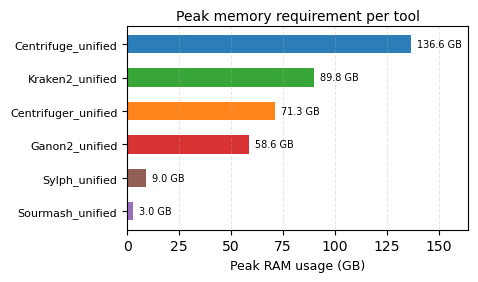

In [42]:
fig_ram = plot_ram_usage(tool_summary)
save_fig(fig_ram, out_figure("ram_usage"), SAVE, dpi=300, bbox_inches="tight")


In [43]:
def plot_dumbbell_per_Mreads(tool_summary):
    """Dumbbell of threaded vs single-core minutes per million reads."""
    df = tool_summary.sort_values("time_per_Mreads_min").copy()
    df[["base_tool", "db_mode"]] = df["tool_db"].str.rsplit("_", n=1, expand=True)

    colors = [TOOL_COLORS.get(t, "gray") for t in df["base_tool"]]
    alphas = [DB_ALPHA.get(db, 0.95)     for db in df["db_mode"]]
    y      = np.arange(len(df))
    wall   = df["time_per_Mreads_min"].values
    cpu    = df["cpu_per_Mreads_min"].values

    fig, ax = plt.subplots(figsize=(5, 3))
    plt.subplots_adjust(left=0.30, right=0.99, top=0.90, bottom=0.20)

    for i in range(len(df)):
        ax.plot([wall[i], cpu[i]], [y[i], y[i]], color="lightgray", linewidth=1.2, zorder=1)
    ax.scatter(wall, y, s=28, color=colors, alpha=alphas, edgecolor="black", linewidth=0.3, zorder=3)
    ax.scatter(cpu,  y, s=28, color=colors, alpha=alphas, edgecolor="black", linewidth=0.3,
               marker="s", zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(df["tool_db"], fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("Minutes per million reads (log scale)", fontsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_title(f"{N_THREADS}-threaded vs single-core runtime per million reads", fontsize=10, pad=5)

    legend_handles = [
        plt.Line2D([0], [0], marker=m, linestyle="", color="black", markersize=5, label=lab)
        for m, lab in [("o", "Threaded wall-clock"), ("s", "Single-core equivalent")]
    ]
    ax.legend(handles=legend_handles, fontsize=7, loc="lower right",
              frameon=False, handlelength=1.5, borderpad=0.2)
    return fig


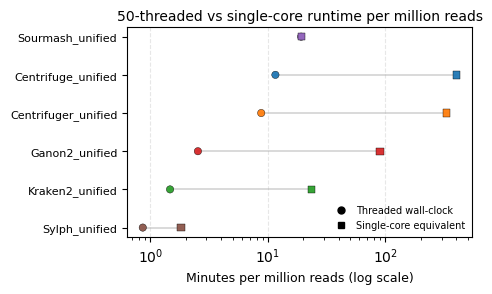

In [44]:
fig_dumbbell = plot_dumbbell_per_Mreads(tool_summary)
save_fig(fig_dumbbell, out_figure("per_mill_reads"), SAVE, dpi=300, bbox_inches="tight")


## CPU vs F1

In [45]:
# Pooled CPU time per Gbp (size-weighted across datasets)
runtime_pooled = (
    runtime_df
    .groupby(["tool", "tool_db", "db"], as_index=False)
    .agg(total_cpu_time_min=("cpu_time_min", "sum"),
         total_bases=("total_bases", "sum"))
)
runtime_pooled["cpu_per_Gbp_min"] = (
    runtime_pooled["total_cpu_time_min"] / (runtime_pooled["total_bases"] / 1e9)
).replace([float("inf"), -float("inf")], pd.NA)

# Mean F1 across datasets, per (tool_db, rank)
acc_mean = (
    metrics.query("rank in ['species', 'genus']")
    .groupby(["tool", "tool_db", "db", "rank"], as_index=False)
    .agg(mean_F1=("F1", "mean"))
)

cpu_f1_df = acc_mean.merge(
    runtime_pooled[["tool", "tool_db", "cpu_per_Gbp_min"]],
    on=["tool", "tool_db"], how="inner",
)
cpu_f1_df


,tool,tool_db,db,rank,mean_F1,cpu_per_Gbp_min
0,Centrifuge,Centrifuge_unified,unified,genus,0.287333,62.170037
1,Centrifuge,Centrifuge_unified,unified,species,0.224010,62.170037
2,Centrifuger,Centrifuger_unified,unified,genus,0.655527,51.324320
3,Centrifuger,Centrifuger_unified,unified,species,0.536832,51.324320
4,Ganon2,Ganon2_unified,unified,genus,0.860937,13.891033
5,Ganon2,Ganon2_unified,unified,species,0.781440,13.891033
6,Kraken2,Kraken2_unified,unified,genus,0.611426,3.652999
7,Kraken2,Kraken2_unified,unified,species,0.394268,3.652999
8,Sourmash,Sourmash_unified,unified,genus,0.895328,2.984668
9,Sourmash,Sourmash_unified,unified,species,0.824775,2.984668


In [46]:
def plot_cpu_vs_f1(cpu_f1_df, title, save_path=None):
    df = cpu_f1_df[cpu_f1_df["cpu_per_Gbp_min"] > 0].copy()
    df[["base_tool", "db"]] = df["tool_db"].str.rsplit("_", n=1, expand=True)

    base_tools = [t for t in BASE_TOOL_ORDER if t in df["base_tool"].unique()]
    marker_map = {"species": "o", "genus": "s"}

    fig, ax = plt.subplots(figsize=(6, 4))
    plt.subplots_adjust(left=0.15, right=0.70, top=0.90, bottom=0.18)

    for _, row in df.iterrows():
        ax.scatter(
            row["cpu_per_Gbp_min"], row["mean_F1"],
            color=TOOL_COLORS[row["base_tool"]],
            alpha=DB_ALPHA[row["db"]],
            marker=marker_map[row["rank"]],
            s=60, edgecolor="black", linewidth=0.3,
        )

    ax.set_xscale("log")
    ax.set_xlabel("CPU time per Gbp (min, single-core equivalent)", fontsize=12)
    ax.set_ylabel("Mean F1 score", fontsize=12)
    ax.set_ylim(0.0, 1.05)
    ax.set_title(title, fontsize=14)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    tool_handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=TOOL_COLORS[t],
                               label=t, markersize=6) for t in base_tools]
    rank_handles = [plt.Line2D([0], [0], marker=marker_map[r], linestyle="", color="black",
                               label=r, markersize=6) for r in ["species", "genus"]]
    leg1 = fig.legend(handles=tool_handles, title="Tool", loc="center left",
                      bbox_to_anchor=(0.73, 0.65), frameon=False, fontsize=11, title_fontsize=11)
    leg2 = fig.legend(handles=rank_handles, title="Rank", loc="center left",
                      bbox_to_anchor=(0.73, 0.35), frameon=False, fontsize=11, title_fontsize=11)

    if save_path:
        save_fig(fig, save_path, SAVE, dpi=300, bbox_inches="tight",
                 bbox_extra_artists=(leg1, leg2), pad_inches=0.25)
    return fig


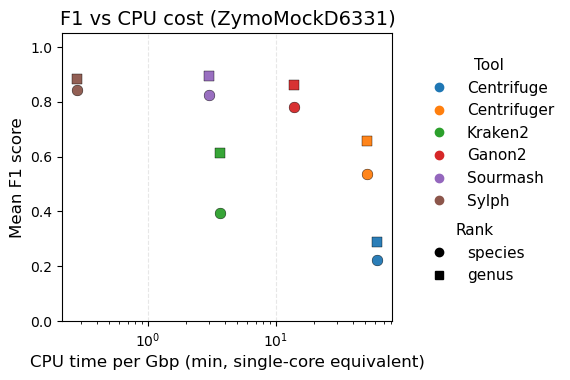

In [47]:
fig = plot_cpu_vs_f1(
    cpu_f1_df,
    title=f"F1 vs CPU cost ({DATA_GROUP})",
    save_path=out_figure("cpu_vs_f1"),
)
